In [ ]:
!git clone -q https://github.com/Mikayla-ds2/surge-sense.git

In [ ]:
%cd surge-sense

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error

%pip install pmdarima
import pmdarima as pm

In [42]:
data = pd.read_csv('/content/drive/MyDrive/daily_visits.csv')

In [43]:
data.head()

,admission_day,visit_count
0,2023-04-01,19
1,2023-04-02,13
2,2023-04-03,14
3,2023-04-04,9
4,2023-04-05,19


In [44]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 579 entries, 0 to 578
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   admission_day  579 non-null    object
 1   visit_count    579 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 9.2+ KB


In [45]:
data['admission_day'] = pd.to_datetime(data['admission_day'])

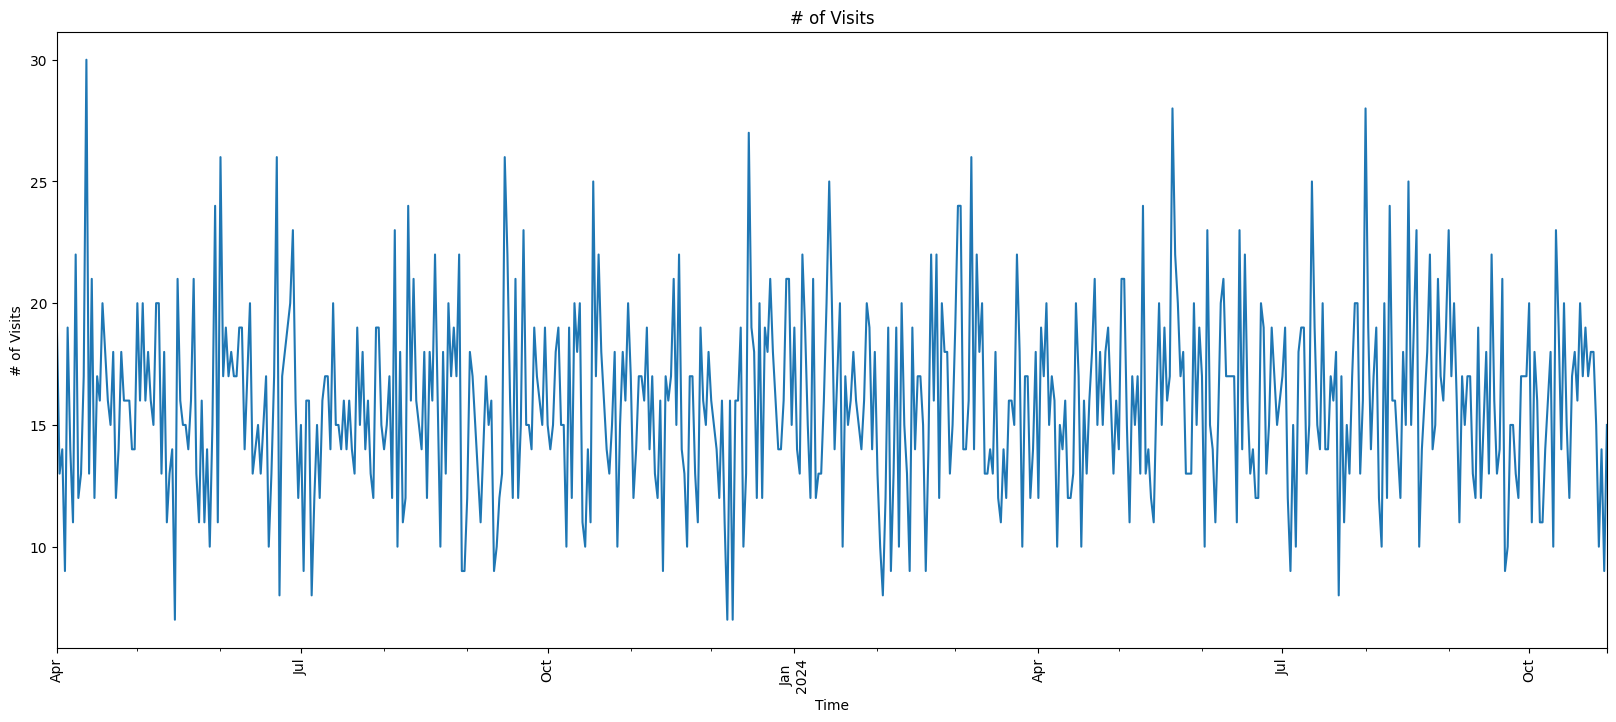

In [46]:
plot = data.plot(x='admission_day', y='visit_count', legend=False, figsize=(20, 8))
plt.xticks(rotation=90, fontsize=10)
plt.title('# of Visits')
plt.xlabel('Time')
plt.ylabel('# of Visits')
plt.show()

In [47]:
data['month_day'] = data['admission_day'].dt.strftime('%m-%d')
data.head()

,admission_day,visit_count,month_day
0,2023-04-01,19,04-01
1,2023-04-02,13,04-02
2,2023-04-03,14,04-03
3,2023-04-04,9,04-04
4,2023-04-05,19,04-05


,month_day,visit_count
222,08-10,48
232,08-20,45
141,05-21,44
258,09-15,44
142,05-22,43
152,06-01,43
284,10-11,43
291,10-18,43
102,04-12,42
154,06-03,42


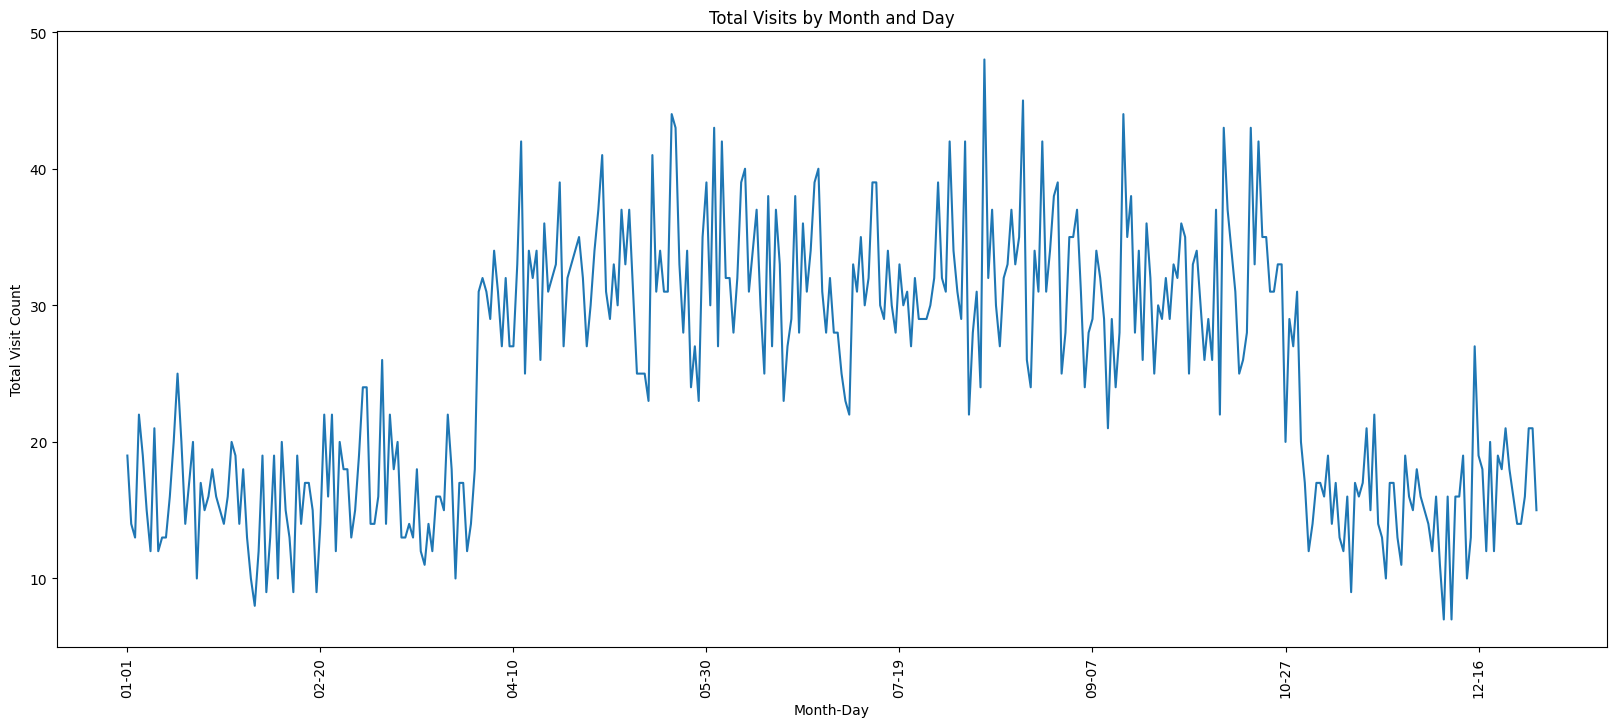

In [48]:
sum_visits = data.groupby('month_day', as_index=False)['visit_count'].sum()
agg_visits_sum = sum_visits.sort_values('month_day')

display(agg_visits_sum.loc[agg_visits_sum['visit_count'].nlargest(10).index])

plot = agg_visits_sum.plot(x='month_day', y='visit_count', legend=False, figsize=(20, 8))
plt.xticks(rotation=90, fontsize=10)
plt.title('Total Visits by Month and Day')
plt.xlabel('Month-Day')
plt.ylabel('Total Visit Count')
plt.show()

,month_day,visit_count
349,12-15,27.0
66,03-07,26.0
13,01-14,25.0
61,03-02,24.0
62,03-03,24.0
222,08-10,24.0
232,08-20,22.5
3,01-04,22.0
51,02-21,22.0
53,02-23,22.0


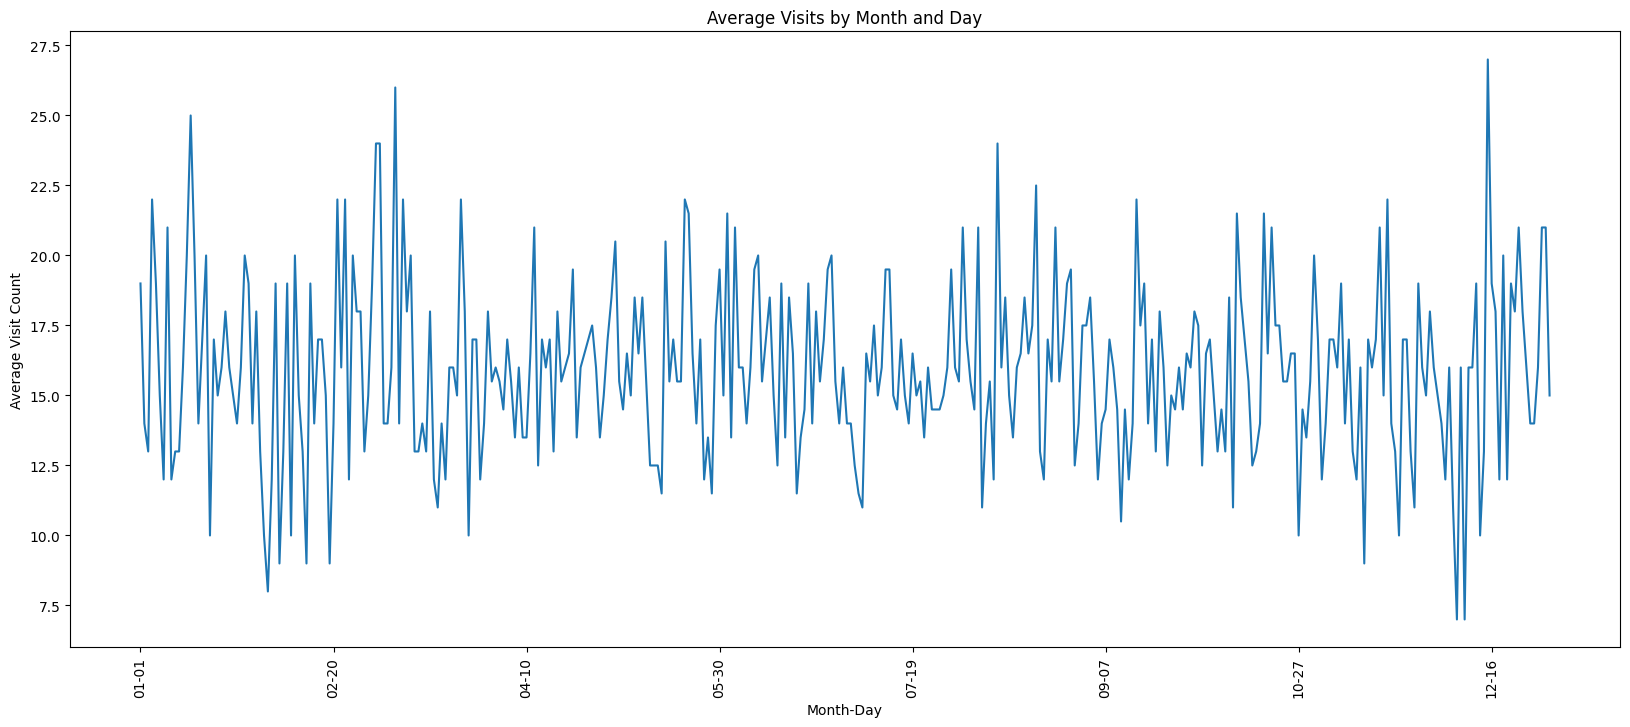

In [49]:
avg_visits = data.groupby('month_day', as_index=False)['visit_count'].mean()
agg_visits_avg = avg_visits.sort_values('month_day')

display(agg_visits_avg.loc[agg_visits_avg['visit_count'].nlargest(10).index])

plot = agg_visits_avg.plot(x='month_day', y='visit_count', legend=False, figsize=(20, 8))
plt.xticks(rotation=90, fontsize=10)
plt.title('Average Visits by Month and Day')
plt.xlabel('Month-Day')
plt.ylabel('Average Visit Count')
plt.show()